# 03 · Exploratory Data Analysis

**Input:** `gold_train.parquet`, `gold_test.parquet`  
**Output:** `figures/eda_*.pdf`, `reports/eda_summary.csv`

In [15]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

GOLD_DIR   = Path('../data/gold')
FIG_DIR    = Path('../figures');   FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = Path('../reports');  REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── palette ──────────────────────────────────────────────────────────────────
PRIMARY, SECONDARY, GREY = '#075020', '#8A7A2F', "#969490"
bok_cmap = LinearSegmentedColormap.from_list('bok', [SECONDARY, PRIMARY])
 
sns.set_theme(style='white')
 
mpl.rcParams.update({
    'figure.figsize':    (10, 6),
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  True,
    'axes.spines.bottom': True,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'legend.frameon':    False,
    'grid.color':        'gray',
    'grid.alpha':        0.3,
})
 
# ── HELPER FUNCTIONS ───────────────────────────────── 
def gridlines_horizontal_only():
    ax = plt.gca()
    ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    print("✓ Gridlines: Horizontal only")
 
 
def no_gridlines():
    ax = plt.gca()
    ax.grid(False)
    print("✓ Gridlines: None")
 
 
def gridlines_subtle():
    ax = plt.gca()
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.2)
    ax.set_axisbelow(True)
    print("✓ Gridlines: Subtle (horizontal only)")
 
 
def save_fig(name):
    plt.savefig(FIG_DIR / name, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {name}')
 


In [3]:
df    = (pd.concat([pd.read_parquet(GOLD_DIR/f)
                    for f in ('gold_train.parquet','gold_test.parquet')])
           .sort_values('date').reset_index(drop=True))
df_sa = df[df.team == 'South Africa'].copy()
print(f'All: {len(df):,} | SA: {len(df_sa)} | SA win rate: {df_sa.win.mean():.1%}')

All: 3,410 | SA: 332 | SA win rate: 62.3%


✓ Gridlines: Horizontal only


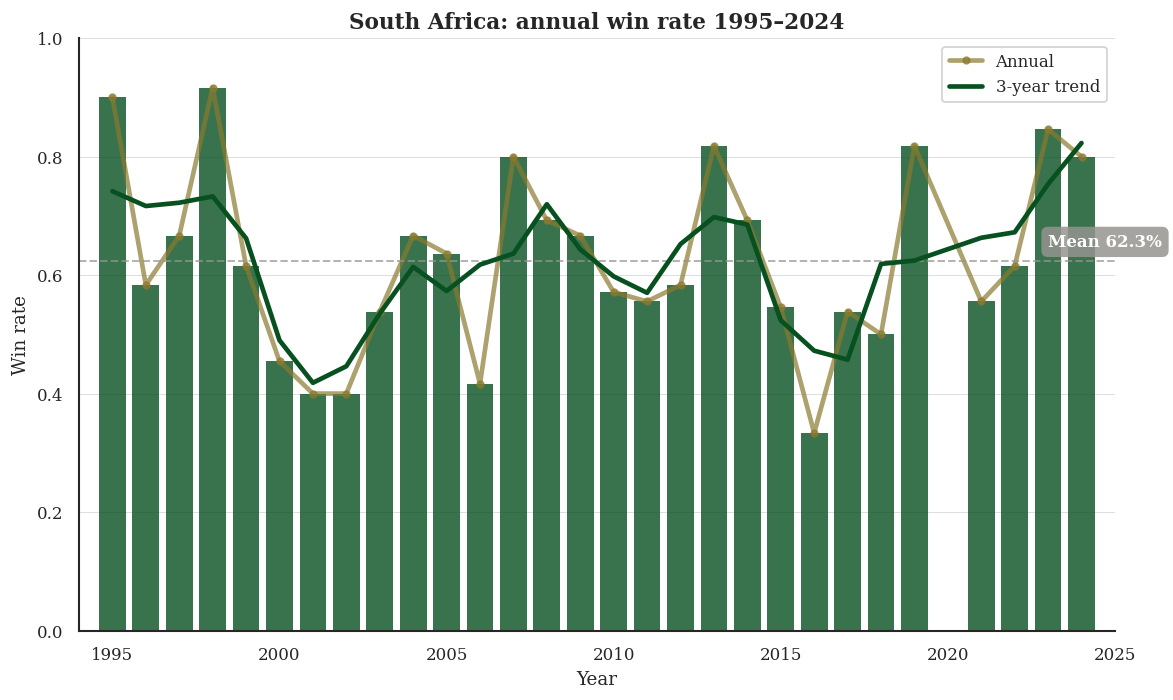

Saved: eda_winrate_trend.pdf


In [27]:
yr      = df_sa.groupby('year').win.agg(rate='mean', n='count')
yr['trend'] = yr.rate.rolling(3, center=True, min_periods=1).mean()
mean_wr = df_sa.win.mean()
 
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(yr.index, yr.rate, color=PRIMARY, alpha=0.8, edgecolor='none', width=0.8, zorder=1)
 
ax.plot(yr.index, yr.rate, color=SECONDARY, lw=2.8, alpha=0.7,
        marker='o', ms=4, label='Annual', zorder=2)
 
ax.plot(yr.index, yr.trend, color=PRIMARY, lw=2.8, label='3-year trend', zorder=3)
 
ax.axhline(mean_wr, color=GREY, ls='--', lw=1.2, alpha=0.7, zorder=2)
 
ax.text(yr.index[-2], mean_wr + 0.025,
        f'Mean {mean_wr:.1%}',
        color='white',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', 
                 facecolor=GREY,
                 edgecolor='none',
                 alpha=0.85),
        zorder=4)
 
ax.set(title='South Africa: annual win rate 1995–2024',
       xlabel='Year', ylabel='Win rate', 
       xlim=(1994, 2025), ylim=(0, 1.0))
 
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
 
# Gridlines
gridlines_horizontal_only() 
 
plt.tight_layout()
save_fig('eda_winrate_trend.pdf')

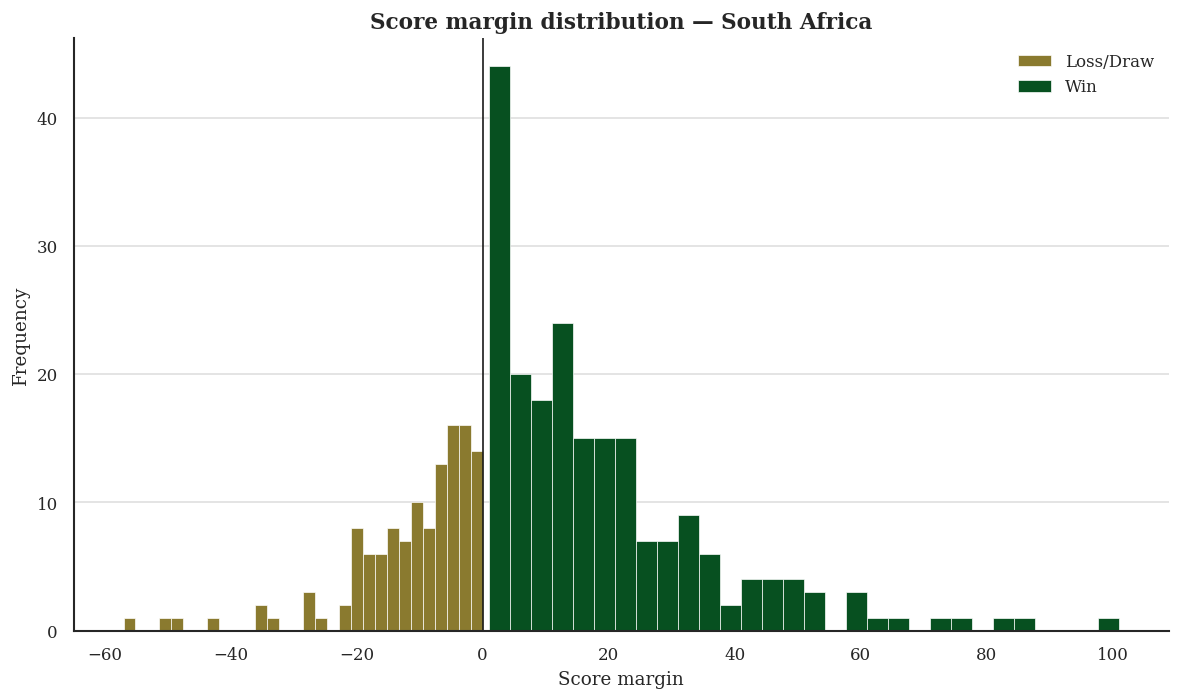

Saved: eda_score_margin.pdf


In [32]:
fig, ax = plt.subplots()  # figsize (10,6) default ✓
kw = dict(bins=30, edgecolor='w', lw=0.4, alpha=1.0)
ax.hist(df_sa[df_sa.win==0].score_margin, color=SECONDARY, label='Loss/Draw', **kw)
ax.hist(df_sa[df_sa.win==1].score_margin, color=PRIMARY,   label='Win',       **kw)
ax.axvline(0, color='k', lw=1)
ax.set(title='Score margin distribution — South Africa',
       xlabel='Score margin', ylabel='Frequency')
ax.legend()
ax.grid(True, alpha=0.25, axis='y')
 
plt.tight_layout()
save_fig('eda_score_margin.pdf')

✓ Gridlines: Horizontal only


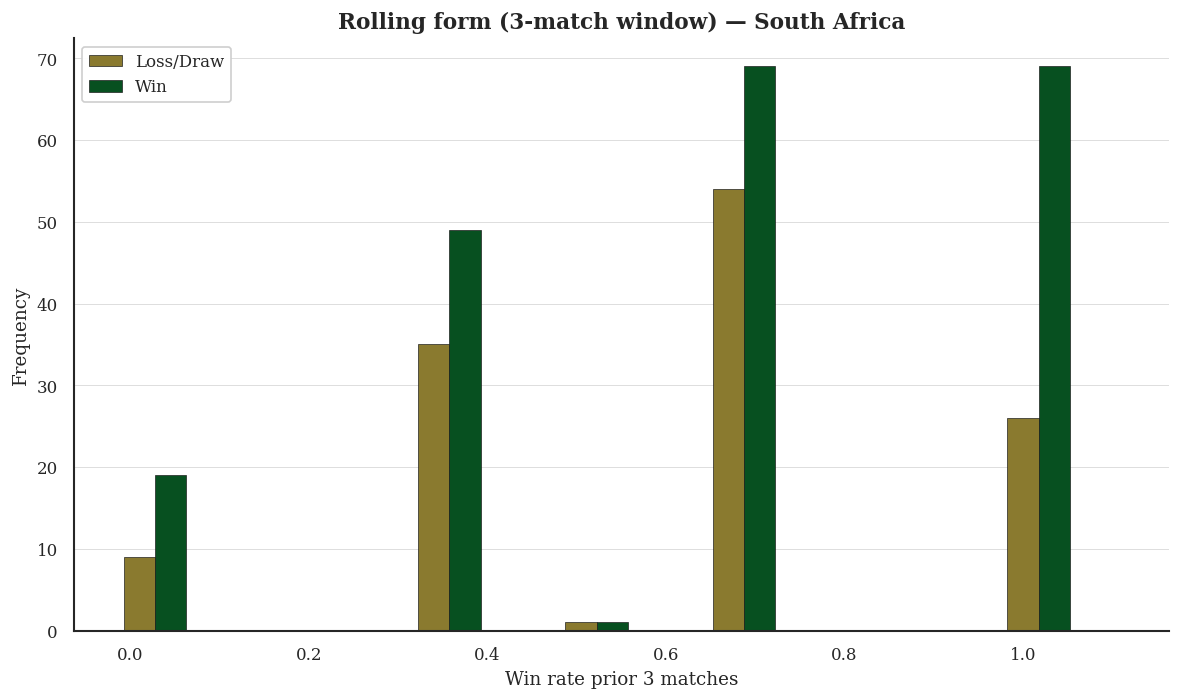

Saved: eda_rolling_form.pdf


In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
 
loss_draw = df_sa[df_sa.win==0].rolling_form_3.dropna()
win = df_sa[df_sa.win==1].rolling_form_3.dropna()
 
bins = np.linspace(0, 1.1, 21)  # 20 Bins von 0 bis 1
hist_loss, edges = np.histogram(loss_draw, bins=bins)
hist_win, _ = np.histogram(win, bins=bins)
 
bin_centers = (edges[:-1] + edges[1:]) / 2
width = 0.035  # Breite der Balken
 
ax.bar(bin_centers - width/2, hist_loss, width, 
       color=SECONDARY, label='Loss/Draw', edgecolor='k', lw=0.4)
 
ax.bar(bin_centers + width/2, hist_win, width, 
       color=PRIMARY, label='Win', edgecolor='k', lw=0.4)
 
ax.set(title='Rolling form (3-match window) — South Africa',
       xlabel='Win rate prior 3 matches', ylabel='Frequency')
 
ax.legend(loc='upper left', frameon=True, framealpha=0.95)
gridlines_horizontal_only()
plt.tight_layout()
save_fig('eda_rolling_form.pdf')

✓ Gridlines: Horizontal only


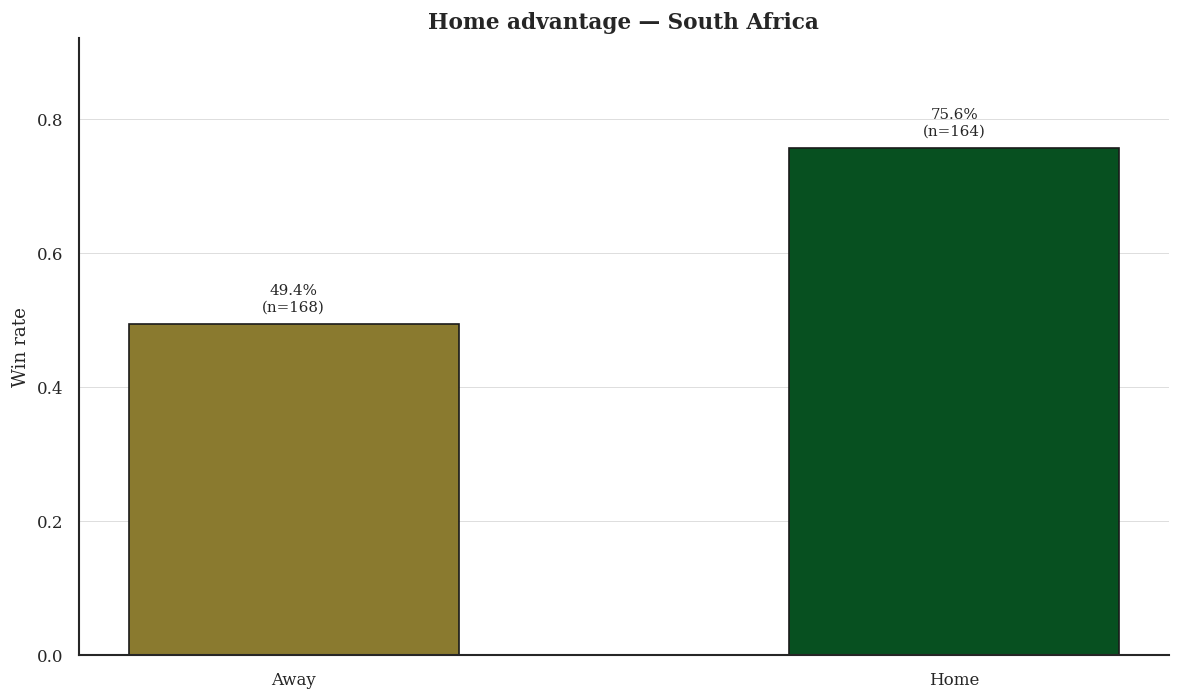

Saved: eda_home_advantage.pdf


In [41]:
ha   = df_sa.groupby('home').win.agg(['mean','count']).reset_index()
 
fig, ax = plt.subplots()  # figsize (10,6) default ✓
bars = ax.bar(['Away','Home'], ha['mean'],
              color=[SECONDARY,PRIMARY], edgecolor='k', lw=1, width=0.5)
for bar, (_, row) in zip(bars, ha.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{row['mean']:.1%}\n(n={int(row['count'])})", ha='center', fontsize=9)
ax.set(title='Home advantage — South Africa',
       ylabel='Win rate', ylim=(0,0.92))
 
gridlines_horizontal_only()  # ← BESSER: Nur horizontale Linien für Bar Charts
 
plt.tight_layout()
save_fig('eda_home_advantage.pdf')

✓ Gridlines: Horizontal only


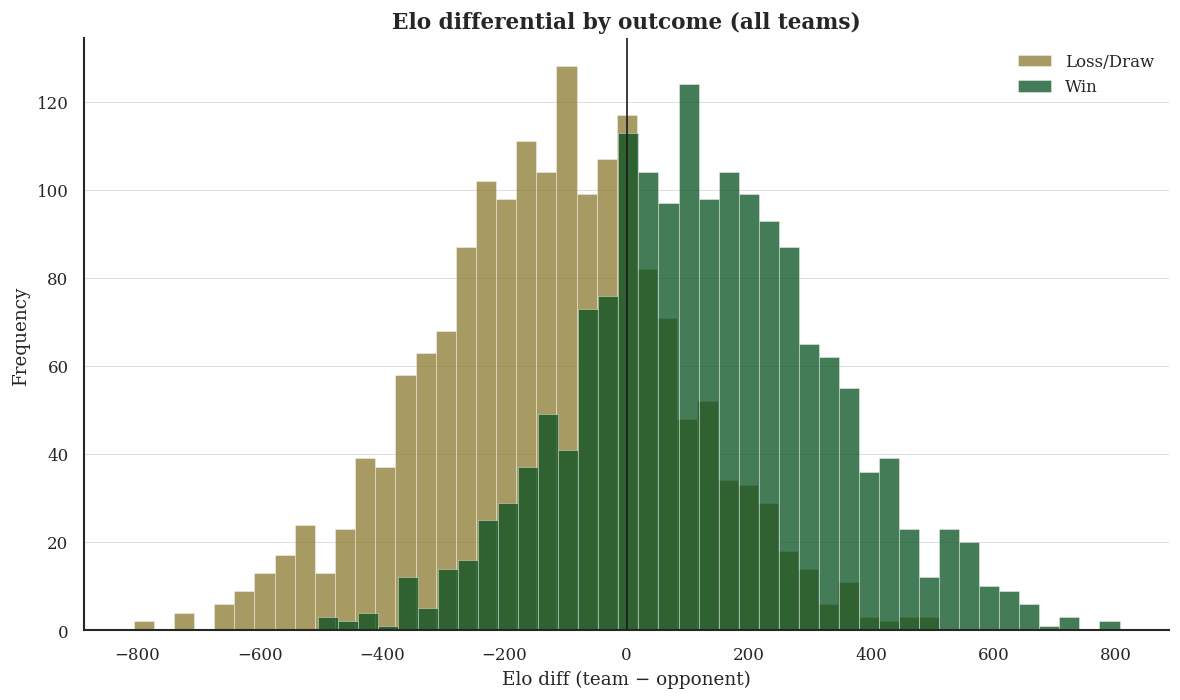

Saved: eda_elo_distribution.pdf


In [44]:
ig, ax = plt.subplots()
kw = dict(bins=40, edgecolor='w', lw=0.3, alpha=0.75)
ax.hist(df[df.win==0].elo_diff_pre, color=SECONDARY, label='Loss/Draw', **kw)
ax.hist(df[df.win==1].elo_diff_pre, color=PRIMARY,   label='Win',       **kw)
ax.axvline(0, color='k', lw=1)
ax.set(title='Elo differential by outcome (all teams)',
       xlabel='Elo diff (team − opponent)', ylabel='Frequency')
ax.legend()
gridlines_horizontal_only()
 
plt.tight_layout()
save_fig('eda_elo_distribution.pdf')

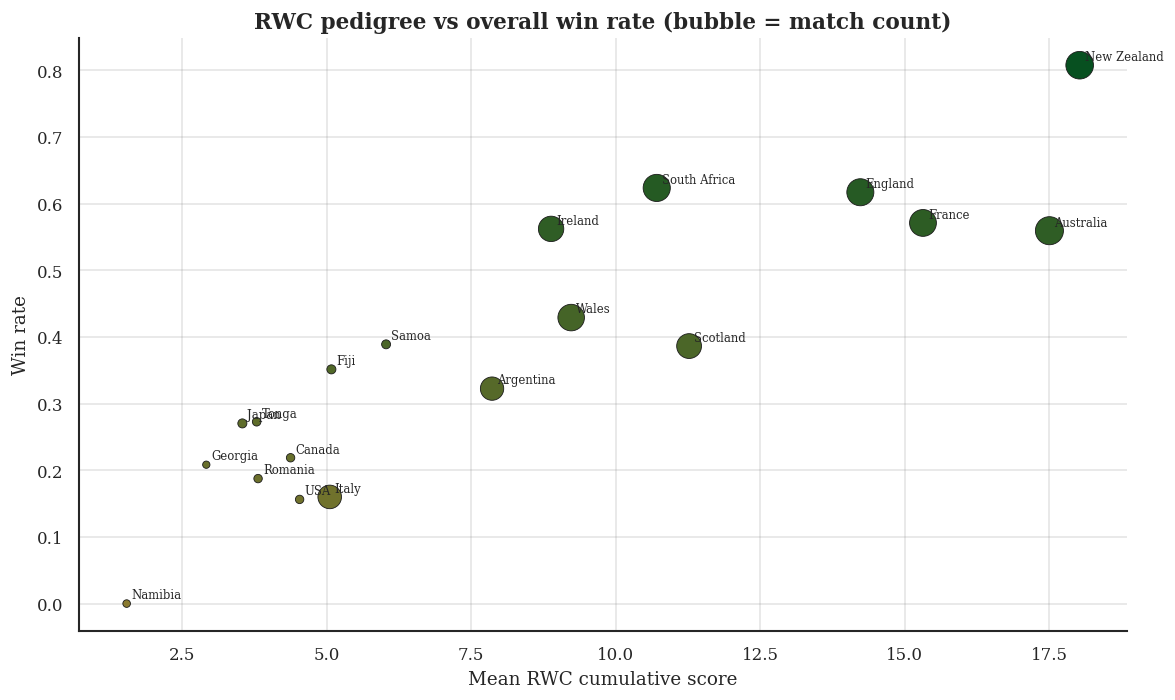

Saved: eda_rwc_pedigree.pdf


In [47]:
team_stats = (df.groupby('team')
                .agg(win_rate=('win','mean'), matches=('win','count'),
                     rwc_score=('rwc_cumul_score','mean'))
                .query('matches >= 20').reset_index())
 
fig, ax = plt.subplots()
sc = ax.scatter(team_stats.rwc_score, team_stats.win_rate,
                s=team_stats.matches*0.8, alpha=1.0,
                c=team_stats.win_rate, cmap=bok_cmap, edgecolors='k', lw=0.5)
for _, row in team_stats.iterrows():
    ax.annotate(row.team, (row.rwc_score, row.win_rate),
                fontsize=7, xytext=(3,3), textcoords='offset points')
ax.set(title='RWC pedigree vs overall win rate (bubble = match count)',
       xlabel='Mean RWC cumulative score', ylabel='Win rate')
ax.grid(True, alpha=0.2)
plt.tight_layout()
save_fig('eda_rwc_pedigree.pdf')

In [10]:
stats = (df.groupby('team')
           .agg(matches=('win','count'), win_rate=('win','mean'),
                avg_margin=('score_margin','mean'),
                avg_elo_diff=('elo_diff_pre','mean'),
                rwc_pedigree=('rwc_cumul_score','mean'))
           .round(3).sort_values('win_rate', ascending=False))
stats.to_csv(REPORT_DIR / 'eda_summary.csv')
print('Saved: eda_summary.csv')
print(stats.to_string())

Saved: eda_summary.csv
              matches  win_rate  avg_margin  avg_elo_diff  rwc_pedigree
team                                                                   
New Zealand       343     0.808      18.437       276.666        18.029
South Africa      332     0.623       7.702        91.118        10.711
England           329     0.617       7.043        94.206        14.234
France            324     0.571       4.009        43.427        15.318
Ireland           290     0.562       3.793        25.310         8.883
Australia         354     0.559       4.282        59.039        17.506
Wales             317     0.429      -1.861       -54.741         9.230
Samoa              36     0.389      -3.639       -33.096         6.028
Scotland          277     0.386      -3.303      -102.553        11.271
Fiji               37     0.351      -6.486       -82.240         5.081
Hong Kong           3     0.333     -22.000        83.324         0.000
Argentina         245     0.322      -6.6

In [11]:
import pandas as pd
from pathlib import Path

silver = pd.read_parquet('../data/silver/silver_results.parquet')
print(silver.groupby('team').size().sort_values().to_string())

team
Kenya             3
Spain             3
Ivory Coast       3
Hong Kong         3
Chile             4
Zimbabwe          6
Russia            8
Portugal         11
Uruguay          19
Georgia          24
Namibia          26
USA              32
Canada           32
Romania          32
Tonga            33
Samoa            36
Japan            37
Fiji             37
Argentina       245
Italy           250
Scotland        277
Ireland         290
Wales           317
France          324
England         329
South Africa    332
New Zealand     343
Australia       354
